<a href="https://colab.research.google.com/github/PragyaKum1/Washington-Phytoplankton/blob/main/rnn_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -O dataset.zip "https://darchive.mblwhoilibrary.org/bitstreams/e1fd23e9-1b79-51a8-a165-1f9bb30177d8/download"
!unzip dataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05036.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05273.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05353.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05715.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05719.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05882.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05890.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_05902.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_06273.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_06363.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_225_161158_06364.png  
 extracting: /content/dataset/2013/Skeletonema/IFCB5_2013_

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image
import os
# os.environ["CUDA_VISIBLE_DEVICES"]="-1" # uncomment to disable GPU
import tensorflow as tf
from tensorflow import keras

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Unique classes found: ['Amphidinium_sp' 'Asterionellopsis' 'Bacillaria' 'Cerataulina'
 'Cerataulina_flagellate' 'Ceratium' 'Chaetoceros' 'Chaetoceros_didymus'
 'Chaetoceros_didymus_flagellate' 'Chaetoceros_flagellate'
 'Chaetoceros_other' 'Chaetoceros_pennate' 'Chrysochromulina'
 'Ciliate_mix' 'Cochlodinium' 'Corethron' 'Coscinodiscus' 'Cylindrotheca'
 'DactFragCerataul' 'Dactyliosolen' 'Delphineis' 'Dictyocha' 'Dinobryon'
 'Dinophysis' 'Ditylum' 'Ditylum_parasite' 'Emiliania_huxleyi' 'Ephemera'
 'Eucampia' 'Euglena' 'Euplotes_sp' 'G_delicatula_detritus'
 'G_delicatula_external_parasite' 'G_delicatula_parasite'
 'Guinardia_delicatula' 'Guinardia_flaccida' 'Guinardia_striata'
 'Gyrodinium' 'Heterocapsa_triquetra' 'Katodinium_or_Torodinium'
 'Laboea_strobila' 'Lauderia' 'Leegaardiella_ovalis' 'Leptocylindrus'
 'Licmophora' 'Mesodinium_sp' 'Odontella' 'Paralia'
 'Parvicorbicula_socialis' 'Phaeocystis' 'Pleuronema_sp' 'Pleurosigma'
 'Prorocentrum' 'Proterythropsis_sp' 'Protoperidinium'
 'P

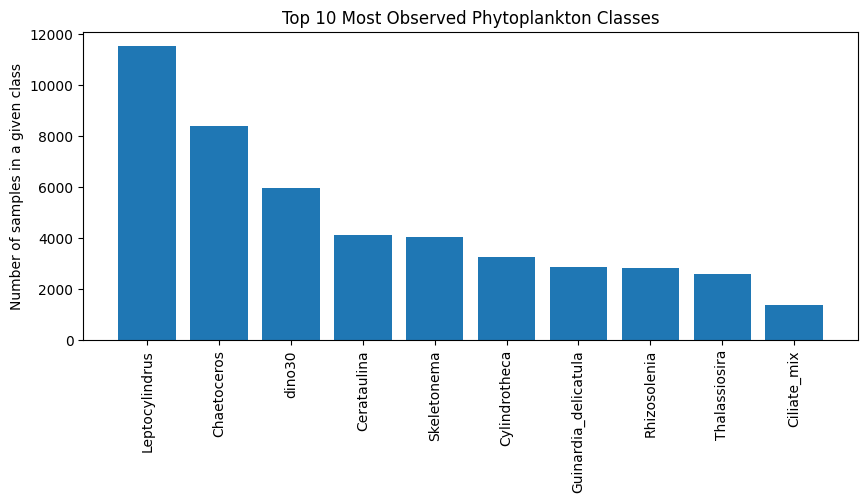

In [3]:
import os
import numpy as np


def png_filenames(data_dir):
    # List to store the file paths and class names
    paths = []
    class_names = []

    # Define a set of phytoplankton classes to exclude from data
    exclude_list = np.array(['mix', 'mix_elongated', 'detritus', 'bad'])

    # Walk through the directory structure under the '2013' folder
    for root, dirs, files in os.walk(data_dir + "2013"):  # Note: we are only interested in files under the 2013 folder
        for file in files:
            if file.endswith(".png"):  # Look for PNG files
                # Extract the class name from the folder name
                class_name = root.split("/")[-1]

                # Skip if the class name is in the exclude_list
                if class_name in exclude_list:
                    continue

                paths.append(os.path.join(root, file))  # Store the file path
                class_names.append(class_name)  # Store the class name

    # Convert to numpy arrays for easier handling
    paths = np.array(paths)
    class_names = np.array(class_names)

    return paths, class_names

# Extract file paths and class names
png_names, class_names = png_filenames("/content/dataset/")

# Check the unique class names
print("Unique classes found:", np.unique(class_names))

# Count unique classes
classes, counts = np.unique(class_names, return_counts=True)

# Sort by count
sorted_indices = np.argsort(-counts)
classes_sorted = classes[sorted_indices]
counts_sorted = counts[sorted_indices]

# Print sorted indices, classes, and counts
print("Sorted indices:", sorted_indices)
print("Classes sorted:", classes_sorted)
print("Counts sorted:", counts_sorted)

# Plot the corrected graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(classes_sorted[:10], counts_sorted[:10])  # Top 10 most observed classes
plt.xticks(rotation='vertical')
plt.ylabel('Number of samples in a given class')
plt.title('Top 10 Most Observed Phytoplankton Classes')
plt.show()


In [4]:
#crop only the center n by n pixel image from the original data, and fill the image to an n by n size if it is smaller than that
def crop_center(im,n):

    nx=im.shape[1]
    ny=im.shape[0]

    if nx<n:
        imm=np.zeros((ny,n))
        imm[:ny,:nx]=im
        im=imm

    nx=im.shape[1]
    ny=im.shape[0]

    if ny<n:
        imm=np.zeros((n,nx))
        imm[:ny,:nx]=im
        im=imm

    nx=im.shape[1]
    ny=im.shape[0]

    im=im[ (ny//2-n//2):(ny//2+n//2),(nx//2-n//2):(nx//2+n//2)]

    return im

In [5]:
import numpy as np
from skimage import io as image



import numpy as np
import matplotlib.image as image

def load_images(a, class_name, keep_classes):
    print('Called load_images function')  # Confirm function execution

    if len(a) == 0 or len(class_name) == 0:
        print('Input lists a or class_name are empty!')
        return None, None, None  # Exit if inputs are empty

    print('Initial class names:', np.unique(class_name))  # Print unique class names before filtering

    # Map class names to indices (0–9)
    class_to_idx = {cls: i for i, cls in enumerate(keep_classes)}

    # Filter and keep only valid classes
    a_keep = []
    class_name_keep = []
    class_labels = []

    for img_path, cls in zip(a, class_name):
        if cls in keep_classes:
            a_keep.append(img_path)
            class_name_keep.append(cls)
            class_labels.append(class_to_idx[cls])  # Assign correct label

    print('Classes to keep:', np.unique(class_name_keep))  # Check remaining classes

    if len(a_keep) == 0:
        print('No images remaining!')
        return None, None, None  # Exit early if no images remain

    # Initialize the image array
    Nsamples = len(a_keep)
    IMAGES = np.zeros((Nsamples, 64, 64))
    IM_class = np.array(class_name_keep)

    print(f'Loading {Nsamples} images into the IMAGES array.')

    # Load each image and crop the center
    for i in range(Nsamples):
        try:
            im = image.imread(a_keep[i])  # Read image
            IMAGES[i, :, :] = crop_center(im, 64)  # Crop to 64x64
        except Exception as e:
            print(f"Error loading image {a_keep[i]}: {e}")

    class_labels = np.array(class_labels)  # Convert to NumPy array

    print('Unique class labels assigned:', np.unique(class_labels))  # Should be [0-9]

    return IMAGES, IM_class, class_labels






In [6]:
import numpy as np

def balance_class_samples(png_names, class_name, keep_classes):
    balanced_png_names = []
    balanced_class_names = []

    # Iterate through the classes we want to keep
    for i in range(len(keep_classes)):
        # Filter png_names and class_names by the current class
        class_name_i = class_name[class_name == keep_classes[i]]
        png_names_i = png_names[class_name == keep_classes[i]]

        # Check if there are any samples for the current class
        if len(png_names_i) == 0:
            print(f"Warning: No images found for class {keep_classes[i]}")
            continue  # Skip to the next class if no images are found

        # Determine the minimum number of samples per class (to balance)
        n_min = min(len(png_names_i), len(png_names))  # Set a minimum number of samples

        # If there are more samples than n_min, randomly select a subset
        if len(png_names_i) > n_min:
            rand_ind = np.random.randint(0, len(png_names_i), n_min)
            rand_ind = np.sort(rand_ind)
            png_names_i = png_names_i[rand_ind]
            class_name_i = class_name_i[rand_ind]

        # Add the balanced images and their labels to the lists
        balanced_png_names.extend(png_names_i)
        balanced_class_names.extend(class_name_i)

    # Return the balanced list of image paths and class names
    return np.array(balanced_png_names), np.array(balanced_class_names)


In [7]:
keep_classes=np.array(classes_sorted[:10])

png_names_balanced,class_name_balanced =balance_class_samples(png_names,class_names,keep_classes)
IMAGES, IM_class, class_labels = load_images(png_names_balanced,class_name_balanced,keep_classes)

Called load_images function
Initial class names: ['Cerataulina' 'Chaetoceros' 'Ciliate_mix' 'Cylindrotheca'
 'Guinardia_delicatula' 'Leptocylindrus' 'Rhizosolenia' 'Skeletonema'
 'Thalassiosira' 'dino30']
Classes to keep: ['Cerataulina' 'Chaetoceros' 'Ciliate_mix' 'Cylindrotheca'
 'Guinardia_delicatula' 'Leptocylindrus' 'Rhizosolenia' 'Skeletonema'
 'Thalassiosira' 'dino30']
Loading 46726 images into the IMAGES array.
Unique class labels assigned: [0 1 2 3 4 5 6 7 8 9]


In [8]:
print("keep_classes:", keep_classes)
print("Number of classes to keep:", len(keep_classes))  # Should be 10
print("Total images after balancing:", len(png_names_balanced))
print("Unique classes after balancing:", np.unique(class_name_balanced))
print("IMAGES shape:", IMAGES.shape)  # Should be (num_samples, 64, 64)
print("IM_class unique values:", np.unique(IM_class))  # Should be the 10 class names
print("class_labels unique values:", np.unique(class_labels))  # Should be [0, 1, ..., 9]


keep_classes: ['Leptocylindrus' 'Chaetoceros' 'dino30' 'Cerataulina' 'Skeletonema'
 'Cylindrotheca' 'Guinardia_delicatula' 'Rhizosolenia' 'Thalassiosira'
 'Ciliate_mix']
Number of classes to keep: 10
Total images after balancing: 46726
Unique classes after balancing: ['Cerataulina' 'Chaetoceros' 'Ciliate_mix' 'Cylindrotheca'
 'Guinardia_delicatula' 'Leptocylindrus' 'Rhizosolenia' 'Skeletonema'
 'Thalassiosira' 'dino30']
IMAGES shape: (46726, 64, 64)
IM_class unique values: ['Cerataulina' 'Chaetoceros' 'Ciliate_mix' 'Cylindrotheca'
 'Guinardia_delicatula' 'Leptocylindrus' 'Rhizosolenia' 'Skeletonema'
 'Thalassiosira' 'dino30']
class_labels unique values: [0 1 2 3 4 5 6 7 8 9]


In [9]:
np.save('IMAGES_2013.npy', IMAGES)
np.save('IM_class_2013.npy', IM_class)
np.save('class_labels_2013.npy', class_labels)

In [10]:
keep_classes=np.array(['Leptocylindrus', 'Chaetoceros', 'dino30' , 'Rhizosolenia', 'Guinardia_delicatula',
                       'Cerataulina', 'Cylindrotheca', 'Skeletonema', 'Thalassiosira', 'Ciliate_mix'])

Machine Learning Part



In [11]:
# reshape the images for input to CNN
X= np.expand_dims(IMAGES, axis=3)
# create the one-hot encoding of the training labels
Y = keras.utils.to_categorical(class_labels, len(keep_classes))


In [12]:
# define a simple RNN model to classify plankton types
def create_rnn_model(input_shape, output_shape):

    x = keras.layers.Input(shape=input_shape)

    y = keras.layers.Conv2D(8, (3,3), activation='relu', padding='same')(x) # add a convolutional layer with a ReLU activation
    y = keras.layers.Conv2D(8, (3,3), activation='relu', padding='same')(y) # add a convolutional layer with a ReLU activation
    #y = keras.layers.Conv2D(8, (3,3), activation='relu', padding='same')(y)
    y = y+x
    y = keras.layers.MaxPooling2D(pool_size=(2,2))(y)     # add a max pooling layer

    y = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(y)
    y0 = y
    #y = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(y)
    y = y0 + y
    y = keras.layers.MaxPooling2D(pool_size=(2,2))(y)

    y = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(y)
    y1 = y
    #y = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(y)
    y = y1 + y
    y = keras.layers.MaxPooling2D(pool_size=(2,2))(y)

    y = keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(y)
    y2 = y
    #y = keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(y)
    y = y2 + y
    y = keras.layers.MaxPooling2D(pool_size=(2,2))(y)

    y = keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(y)
    y3 = y
    #y = keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(y)
    y = keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(y)
    y = y3 + y
    y = keras.layers.MaxPooling2D(pool_size=(2,2))(y)

    y = keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')(y)

    y = keras.layers.GlobalAveragePooling2D()(y)

    y = keras.layers.Dropout(0.5)(y)

    y = keras.layers.Dense(output_shape, activation='softmax')(y)     # add final output layer with a softmax activation

    model = keras.models.Model(inputs=x, outputs=y)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

In [13]:
RNN = create_rnn_model(input_shape=(64,64,1), output_shape=len(keep_classes))

In [14]:
%%time
# fraction of the dataset to use for validation
val_split=0.2

# randomly select the val indices to ensure random mix of classes
ind_val= (np.random.rand(X.shape[0])<val_split)

X_val=X[ind_val]
Y_val=Y[ind_val]

class_labels_val=class_labels[ind_val]

# remaining data goes in the training dataset
X_train=X[~ind_val]
Y_train=Y[~ind_val]

# train the model, and save the progress to hist (hist will be a dictionary)
n_epochs = 25
hist = RNN.fit(x = X_train, y = Y_train, epochs=n_epochs, batch_size=512, validation_data=(X_val,Y_val))

Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 220ms/step - accuracy: 0.2658 - loss: 2.0112 - val_accuracy: 0.4598 - val_loss: 1.4653
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.4866 - loss: 1.4492 - val_accuracy: 0.6615 - val_loss: 0.9641
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6851 - loss: 0.9039 - val_accuracy: 0.7476 - val_loss: 0.7202
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.7519 - loss: 0.7211 - val_accuracy: 0.7632 - val_loss: 0.6678
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.7738 - loss: 0.6493 - val_accuracy: 0.7900 - val_loss: 0.6050
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8067 - loss: 0.5691 - val_accuracy: 0.7957 - val_loss: 0.5740
Epoch 7/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8089 - loss: 0.5506 - val_accuracy: 0.8153 - val_loss: 0.5309
Epoch 8/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8323 - loss: 0.4961 - val_accuracy: 0.8352 -

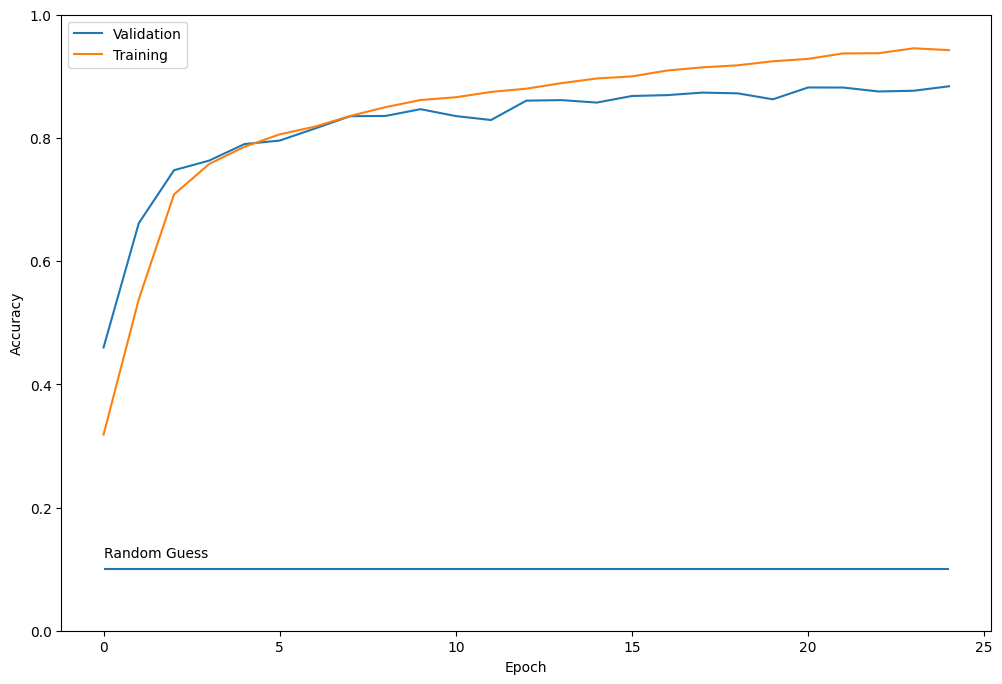

In [15]:
# plot how the accuracy on the training and validation datasets evolved during training
plt.figure(figsize=(12,8))
plt.plot(hist.history['val_accuracy'],label='Validation')
plt.plot(hist.history['accuracy'],label='Training')
plt.ylim([0,1])
plt.hlines(0.1,0,n_epochs-1)
plt.annotate('Random Guess',(0, 0.12))
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy');